#실행8_1_1

In [ ]:
#주로 사용하는 library import
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

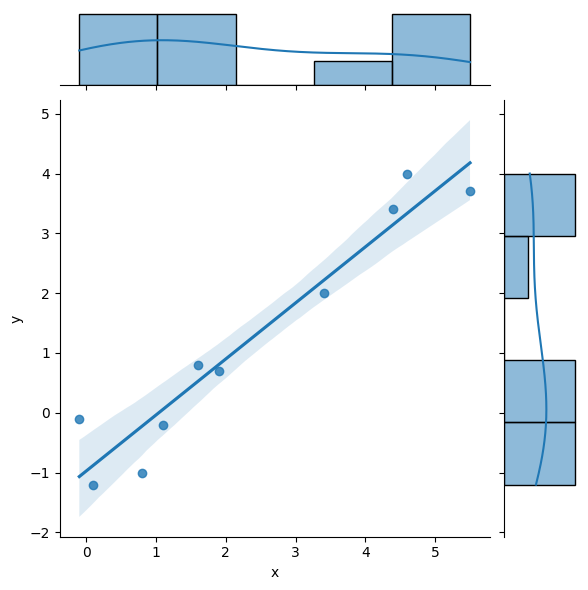

상관계수 r: 0.9617
p-value: 1e-05


In [ ]:
#단순회귀
#data
x = np.array([1.9, 0.8, 1.1, 0.1, -0.1, 4.4, 4.6, 1.6, 5.5, 3.4])
y = np.array([0.7, -1.0, -0.2, -1.2, -0.1, 3.4, 4.0, 0.8, 3.7, 2.0])
df_simple = pd.DataFrame({'x': x, 'y': y})

#산점도
sns.jointplot(x='x', y='y', data=df_simple, kind='reg')
plt.show()

#상관계수/ 상관분석
r, p = stats.pearsonr(df_simple['x'] , df_simple['y'])
print("상관계수 r:", round(r,4))
print("p-value:", round(p,5))

In [ ]:
df_simple_corr=df_simple.corr()
print(df_simple_corr)

          x         y
x  1.000000  0.961705
y  0.961705  1.000000


In [ ]:
#회귀모형적합
import statsmodels.formula.api as smf
lm_simple= smf.ols("y~x", df_simple).fit()
lm_simple

In [ ]:
dir(lm_simple)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'eigenvals',
 'el_test',
 'ess',
 'f_pvalue',
 'f_test',
 'fittedvalues',
 'fvalue',
 'get_influe

In [ ]:
print(lm_simple.params) # 회귀계수
print(lm_simple.rsquared) # R^2
print(lm_simple.pvalues) # p-value들
print(lm_simple.resid.head(5)) # 잔차

Intercept   -0.972506
x            0.936698
dtype: float64
0.924876035001212
Intercept    0.008988
x            0.000009
dtype: float64
0   -0.107220
1   -0.776852
2   -0.257861
3   -0.321163
4    0.966176
dtype: float64


In [ ]:
#결과표
print(lm_simple.summary())
# H0: 회귀 계수가 0이다. H1: 회귀 계수가 0이 아니다

import statsmodels.api as sm
print(sm.stats.anova_lm(lm_simple))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     98.49
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           8.98e-06
Time:                        05:42:26   Log-Likelihood:                -7.3987
No. Observations:                  10   AIC:                             18.80
Df Residuals:                       8   BIC:                             19.40
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9725      0.284     -3.428      0.0

In [ ]:
#새 데이터 예측
new = pd.DataFrame({'x': [10, 20, 30]})
new['y_hat'] = lm_simple.predict(new)
print(new)

    x      y_hat
0  10   8.394474
1  20  17.761453
2  30  27.128433


#실행 8_2_1. 다중회귀식의 적합

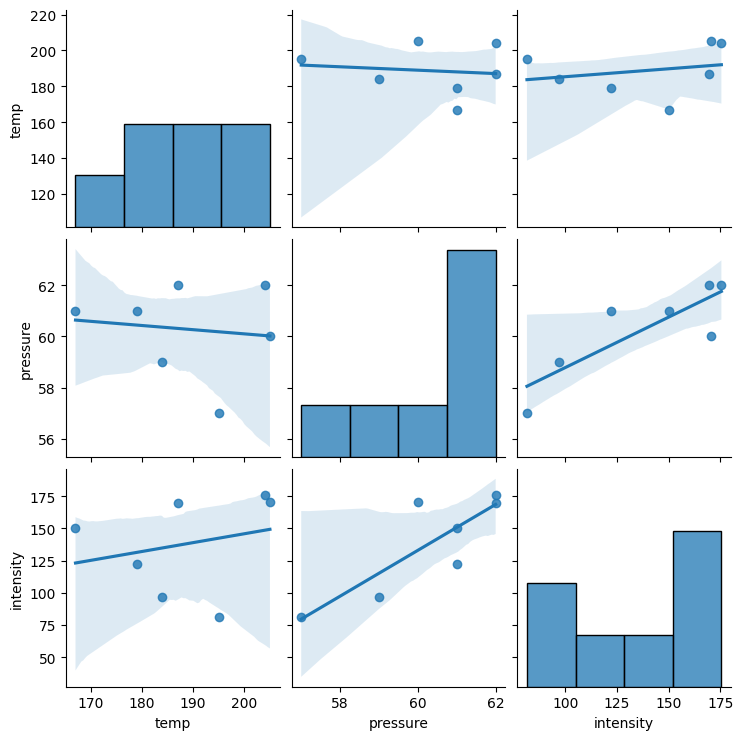

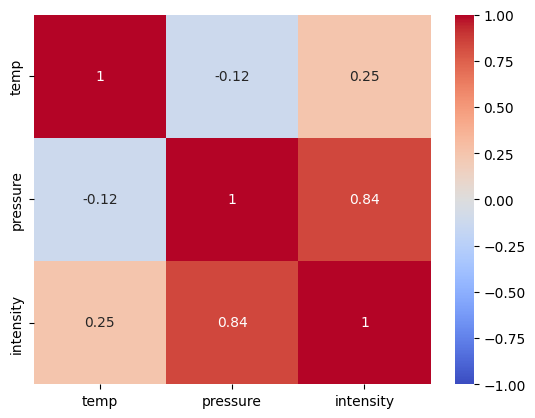

               temp  pressure  intensity
temp       1.000000 -0.124406   0.246716
pressure  -0.124406  1.000000   0.837143
intensity  0.246716  0.837143   1.000000


In [ ]:
#다중회귀
#data
df_multi = pd. DataFrame({'temp': [195, 179, 205, 204, 167, 184, 187],
 'pressure': [57, 61, 60, 62, 61, 59, 62],
 'intensity':[81.4, 122.2, 170.7, 175.6, 150.3, 96.8, 169.8]})

#산점도
sns.pairplot(data=df_multi, kind='reg')
plt.show()

#상관계수
df_corr = df_multi.corr()
sns.heatmap(data=df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()
print(df_corr)

In [ ]:
#회귀모형적합
lm_multi= smf.ols('intensity~temp+pressure', df_multi).fit()  #그렇다고 temp를 무조건 빼는 것은 아님
lm_multi= smf.ols('intensity~temp+pressure', data=df_multi).fit()
#결과표
print(lm_multi.summary())
print(sm.stats.anova_lm(lm_multi))
print(lm_multi.params)

                            OLS Regression Results                            
Dep. Variable:              intensity   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     9.484
Date:                Sun, 30 Nov 2025   Prob (F-statistic):             0.0303
Time:                        06:11:19   Log-Likelihood:                -28.792
No. Observations:                   7   AIC:                             63.58
Df Residuals:                       4   BIC:                             63.42
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1180.2817    304.169     -3.880      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
#새 데이터 예측
new = pd.DataFrame({'temp': [180, 190, 200],
 'pressure': [59, 60, 62]})
new['pred_intensity'] = lm_multi.predict(new)
print(new)

   temp  pressure  pred_intensity
0   180        59      105.332824
1   190        60      134.034175
2   200        62      181.491385


#연습8_1_1

['MedHouseVal']


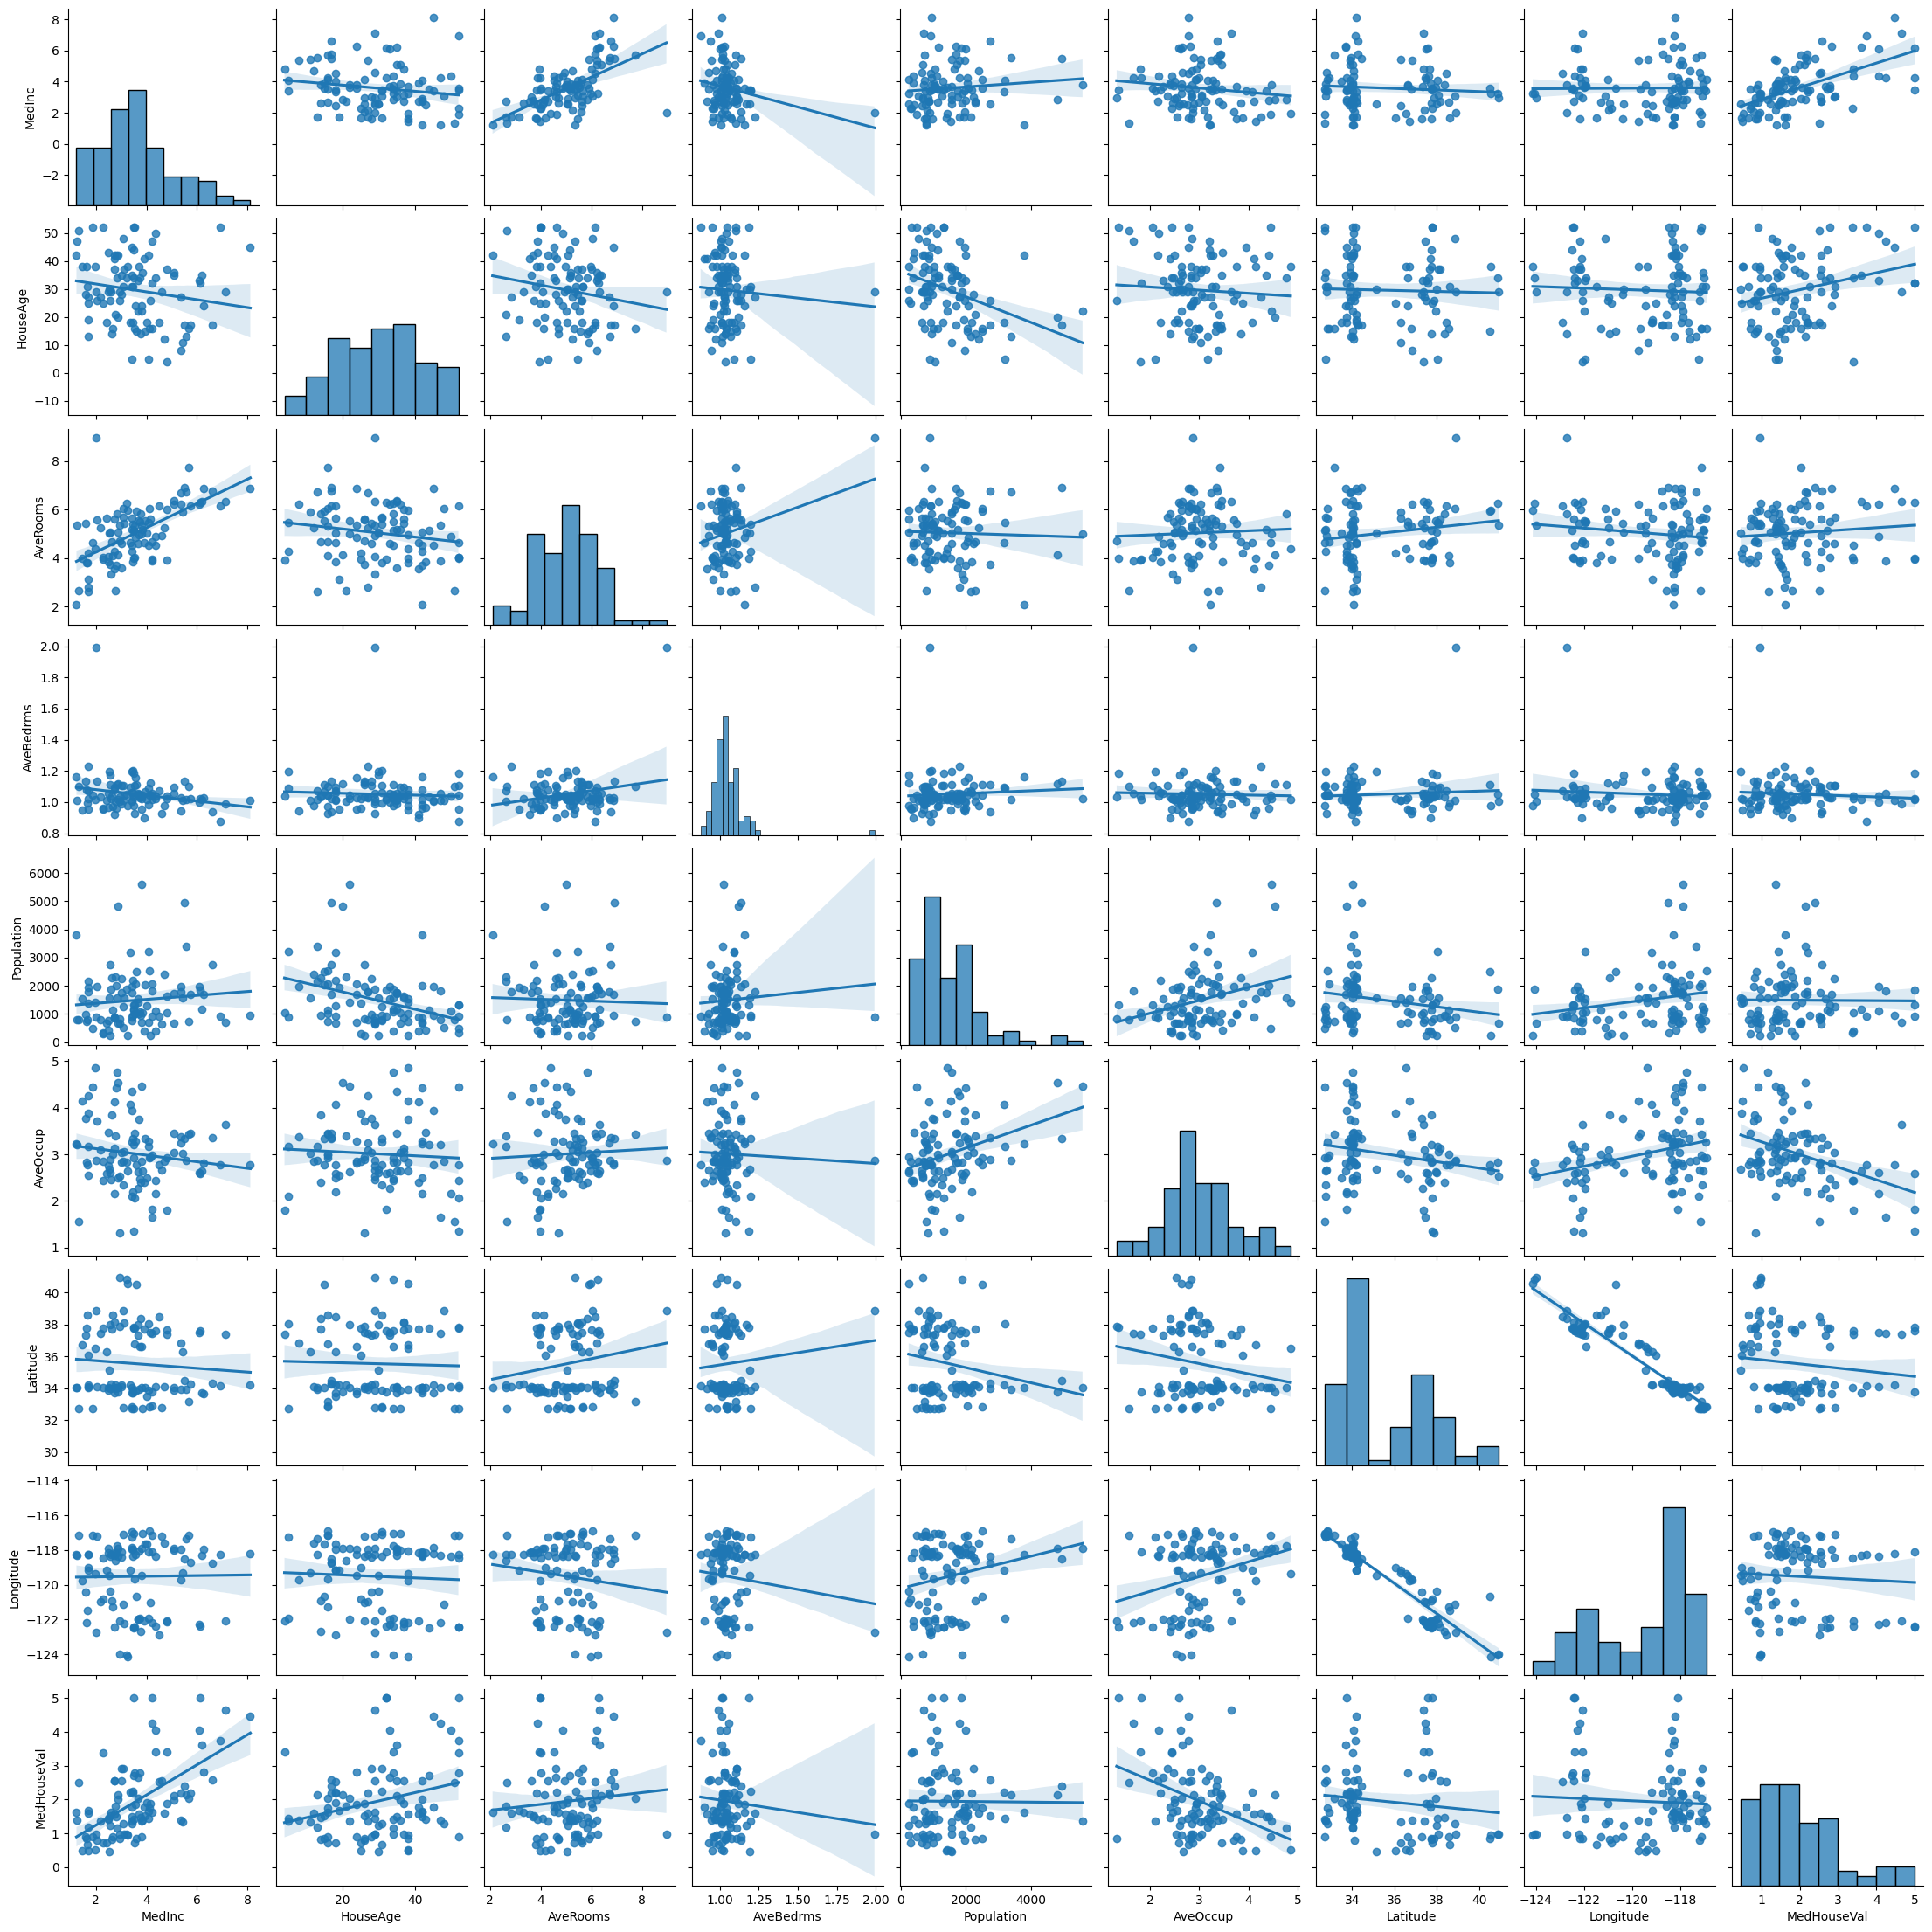

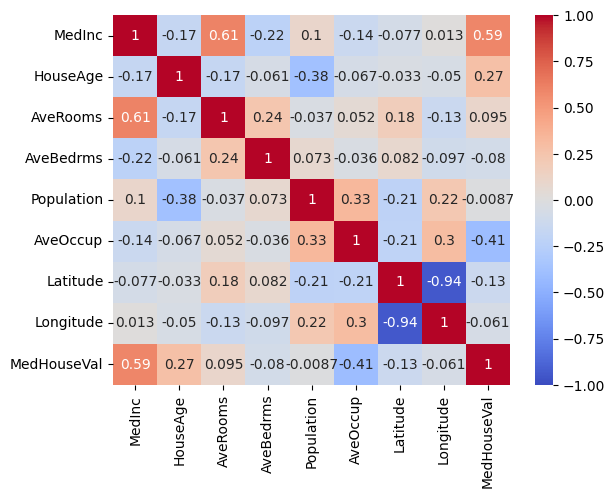

In [ ]:
from sklearn.datasets import fetch_california_housing  #fetch하는 모듈이 있음
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing["MedHouseVal"] = housing.target #target은 종속변수 배열

df_sample = df_housing.sample(100, random_state=42)

#산점도
sns.pairplot(data=df_sample, kind='reg')
plt.show()

#상관계수
df_corr = df_sample.corr()
sns.heatmap(data=df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)  #data= 써도 되고 안써도 됨
plt.show()

#연습 8_1_2

In [ ]:
import statsmodels.formula.api as smf
lm_housing= smf.ols("MedHouseVal~MedInc", df_housing).fit()
print(lm_housing.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        06:26:42   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4509      0.013     34.082      0.0

#연습 8_1_3

In [ ]:
lm_housing2= smf.ols('MedHouseVal ~ MedInc + AveRooms + AveOccup', data=df_housing).fit()

#결과표
print(lm_housing2.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     6370.
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        06:28:26   Log-Likelihood:                -25477.
No. Observations:               20640   AIC:                         5.096e+04
Df Residuals:                   20636   BIC:                         5.099e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6069      0.016     37.444      0.0